In [ ]:
import tensorflow as tf

print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


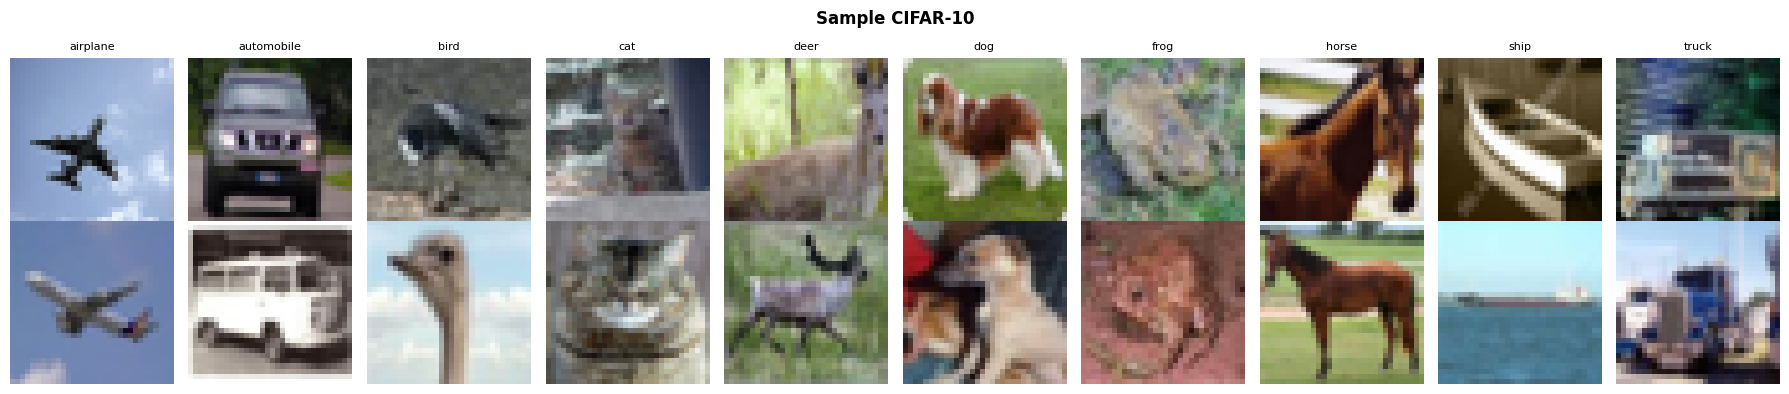

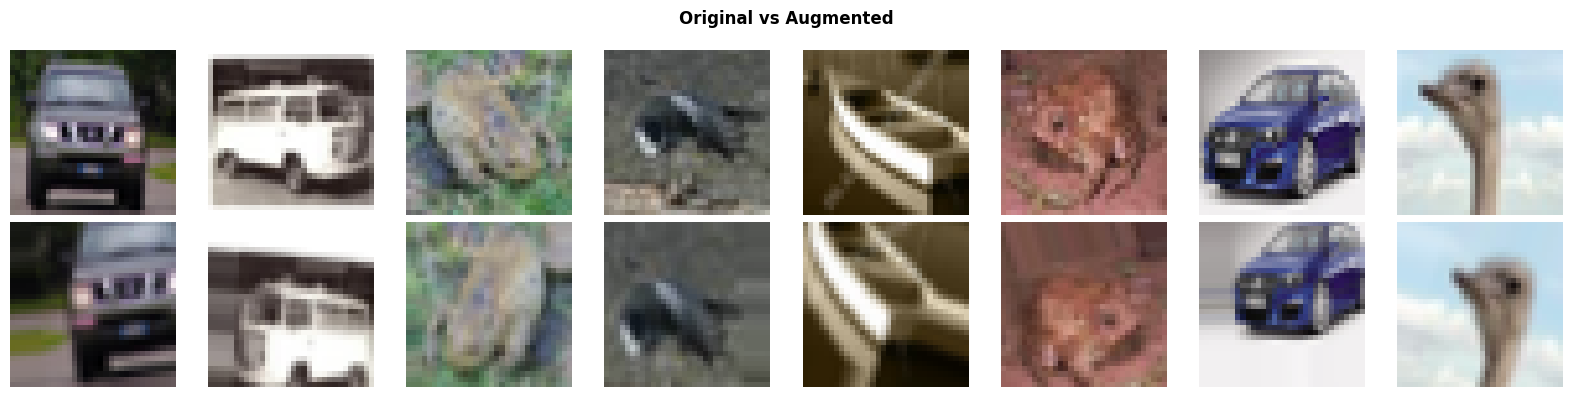

Training base_adam...
  Acc=0.7644
Training base_sgd...
  Acc=0.4141
Training base_adam_aug...


  Acc=0.4458
Training deep_adam_aug...
  Acc=0.4585
Training wide_adam...
  Acc=0.6106


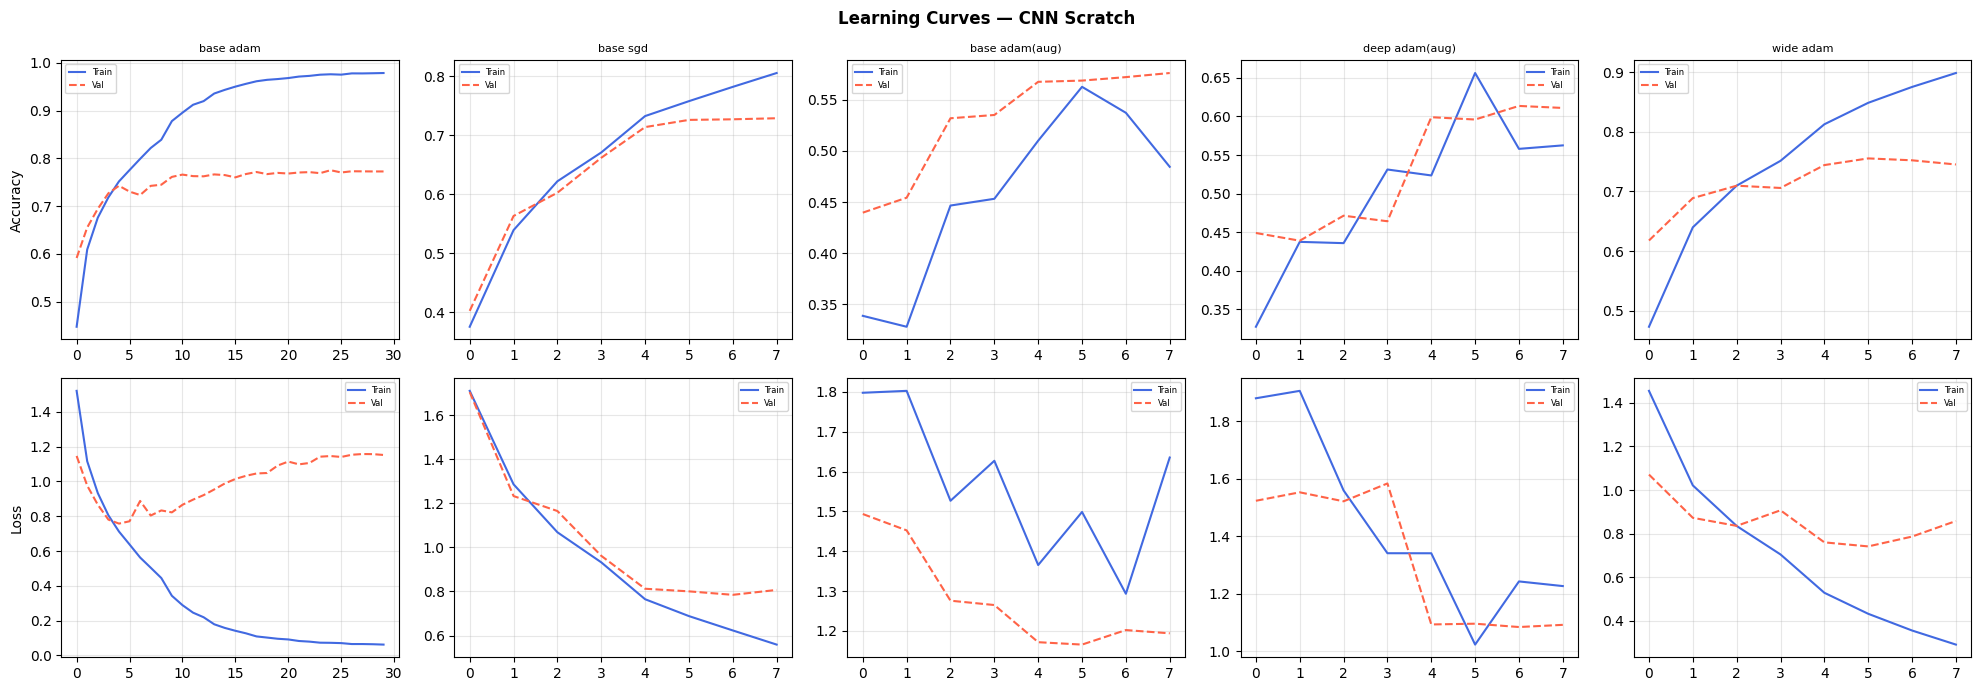


Best scratch: base_adam


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,579,680 (25.10 MB)

 Trainable params: 2,193,226 (8.37 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,386,454 (16.73 MB)


CNN Scratch (base_adam)
               precision    recall  f1-score   support

    airplane       0.79      0.82      0.80      1000
  automobile       0.88      0.85      0.87      1000
        bird       0.69      0.66      0.68      1000
         cat       0.56      0.57      0.57      1000
        deer       0.73      0.75      0.74      1000
         dog       0.69      0.64      0.66      1000
        frog       0.82      0.82      0.82      1000
       horse       0.81      0.80      0.80      1000
        ship       0.86      0.87      0.87      1000
       truck       0.81      0.85      0.83      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



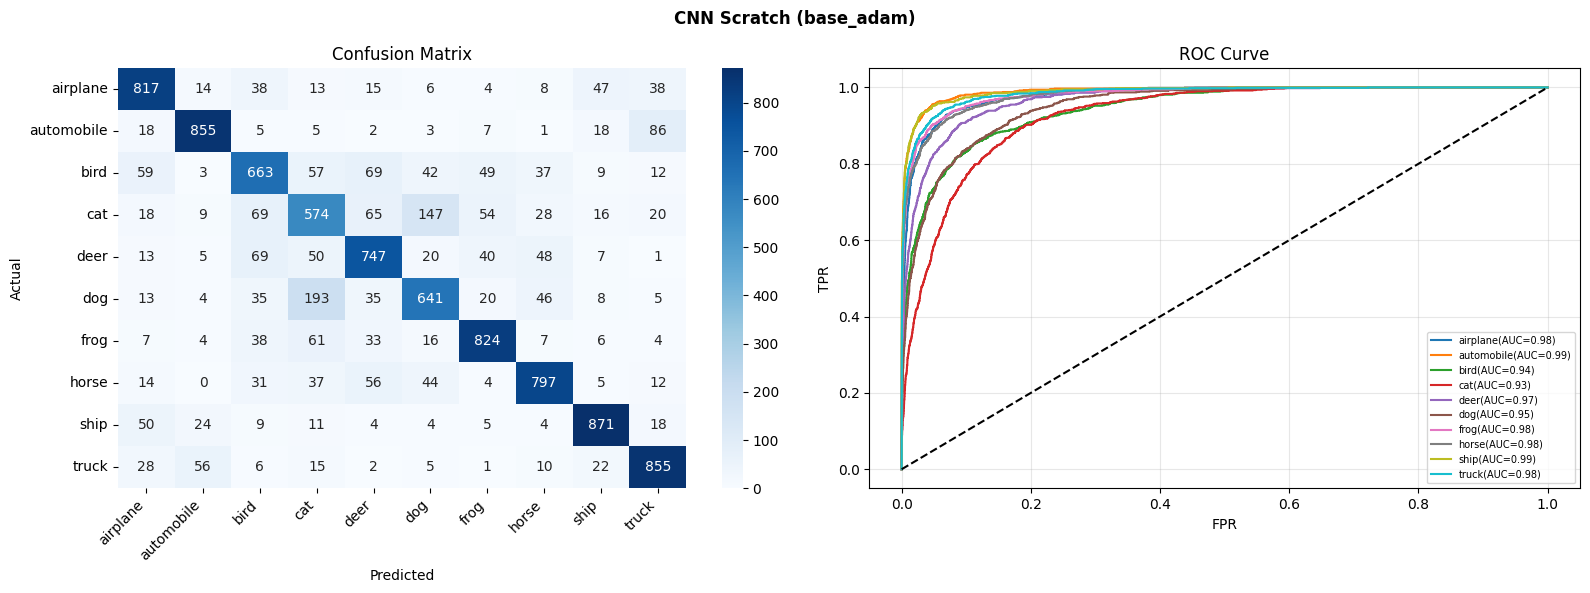

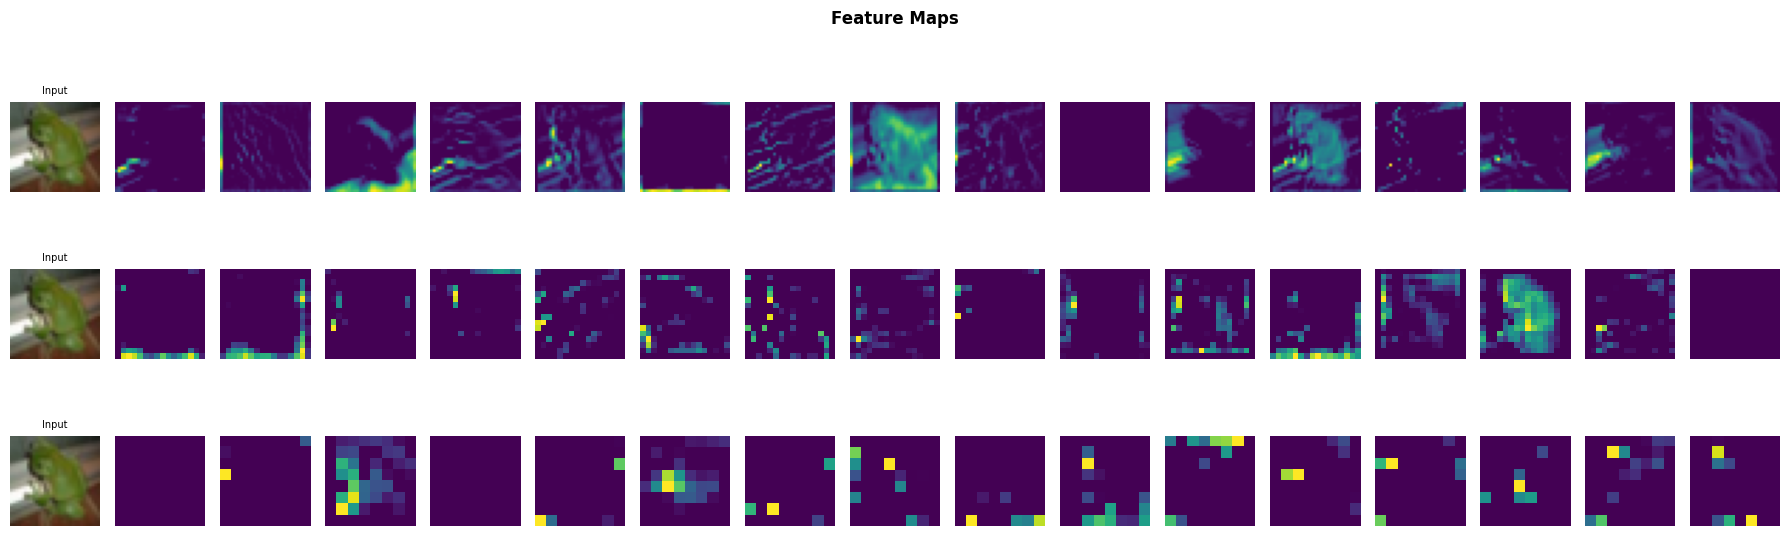

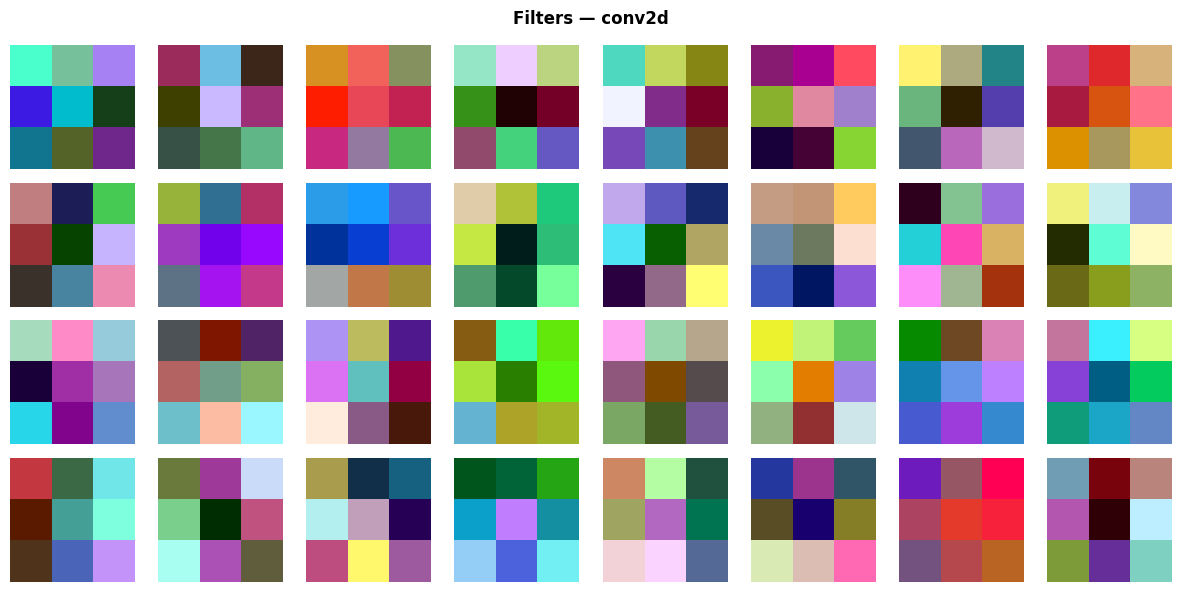

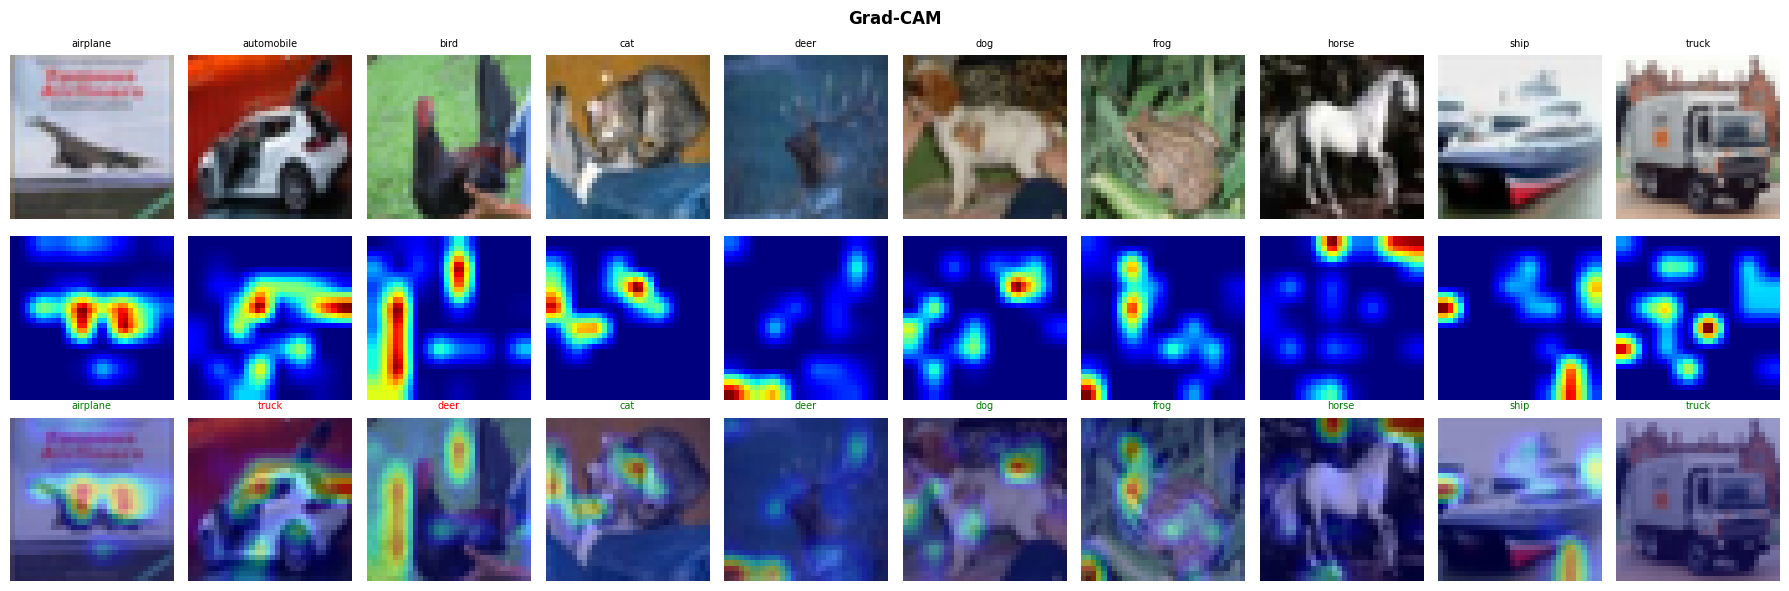

t-SNE...


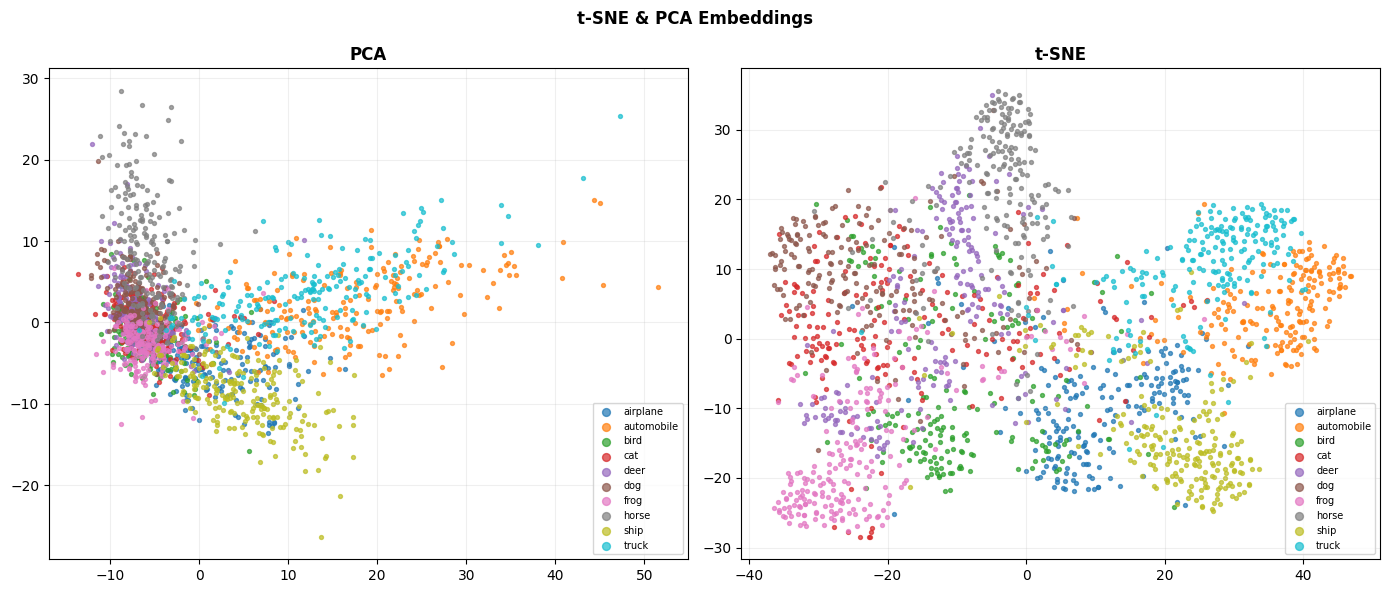

Resizing...


In [ ]:
# CNN Klasifikasi Citra: Scratch → Transfer Learning | CIFAR-10 | Colab Ready
import os, time, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm, seaborn as sns, cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ── Setup ──────────────────────────────────────────────────────
NC=10; SZ=32; NAMES=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
RESULTS={}; np.random.seed(42); tf.random.set_seed(42)

# ── 1. Dataset ─────────────────────────────────────────────────
(Xtr,ytr),(Xte,yte) = keras.datasets.cifar10.load_data()
Xtr,Xte = Xtr.astype('float32')/255, Xte.astype('float32')/255
ytr,yte = ytr.flatten(), yte.flatten()
Xtr,Xv,ytr,yv = train_test_split(Xtr,ytr,test_size=0.1,stratify=ytr,random_state=42)
Ytrc,Yvc,Ytec = [keras.utils.to_categorical(y,NC) for y in [ytr,yv,yte]]

fig,ax=plt.subplots(2,NC,figsize=(18,4)); fig.suptitle("Sample CIFAR-10",fontweight='bold')
for c in range(NC):
    idx=np.where(ytr==c)[0][:2]
    for r,i in enumerate(idx): ax[r,c].imshow(Xtr[i]); ax[r,c].axis('off'); ax[0,c].set_title(NAMES[c],fontsize=8)
plt.tight_layout(); plt.savefig('01_dataset.png',dpi=100); plt.show()

# ── 2. Augmentation ────────────────────────────────────────────
dg=ImageDataGenerator(rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,
                      horizontal_flip=True,zoom_range=0.2,shear_range=0.2,fill_mode='nearest')
dg.fit(Xtr)
fig,ax=plt.subplots(2,8,figsize=(16,4)); fig.suptitle("Original vs Augmented",fontweight='bold')
for c in range(8):
    ax[0,c].imshow(Xtr[c]); ax[0,c].axis('off')
    ax[1,c].imshow(np.clip(next(dg.flow(Xtr[c:c+1],batch_size=1))[0],0,1)); ax[1,c].axis('off')
ax[0,0].set_ylabel("Original"); ax[1,0].set_ylabel("Augmented")
plt.tight_layout(); plt.savefig('02_augmentation.png',dpi=100); plt.show()

# ── 3. CNN Scratch ─────────────────────────────────────────────
def build(variant='base',opt='adam',lr=0.001):
    i=keras.Input(shape=(SZ,SZ,3))
    if variant=='base':
        x=layers.Conv2D(32,(3,3),activation='relu',padding='same')(i)
        x=layers.MaxPooling2D(2)(x); x=layers.Conv2D(64,(3,3),activation='relu',padding='same')(x)
        x=layers.MaxPooling2D(2)(x); x=layers.Conv2D(128,(3,3),activation='relu',padding='same')(x)
        x=layers.Flatten()(x); x=layers.Dense(256,activation='relu')(x); x=layers.Dropout(0.5)(x)
    elif variant=='deep':
        x=i
        for f in [32,64,128]:
            x=layers.Conv2D(f,(3,3),activation='relu',padding='same')(x); x=layers.BatchNormalization()(x)
            x=layers.Conv2D(f,(3,3),activation='relu',padding='same')(x); x=layers.BatchNormalization()(x)
            x=layers.MaxPooling2D(2)(x); x=layers.Dropout(0.25)(x)
        x=layers.Flatten()(x); x=layers.Dense(512,activation='relu')(x); x=layers.Dropout(0.5)(x)
    elif variant=='wide':
        x=layers.Conv2D(64,(3,3),activation='relu',padding='same')(i); x=layers.MaxPooling2D(2)(x)
        x=layers.Conv2D(128,(3,3),activation='relu',padding='same')(x); x=layers.MaxPooling2D(2)(x)
        x=layers.Conv2D(256,(3,3),activation='relu',padding='same')(x)
        x=layers.Flatten()(x); x=layers.Dense(512,activation='relu')(x); x=layers.Dropout(0.5)(x)
    out=layers.Dense(NC,activation='softmax',name='output')(x)
    m=keras.Model(i,out)
    o={'adam':keras.optimizers.Adam(lr),'sgd':keras.optimizers.SGD(lr,momentum=0.9,nesterov=True)}[opt]
    m.compile(optimizer=o,loss='categorical_crossentropy',metrics=['accuracy']); return m

CBS=[keras.callbacks.EarlyStopping('val_accuracy',patience=8,restore_best_weights=True),
     keras.callbacks.ReduceLROnPlateau('val_loss',factor=0.5,patience=4,min_lr=1e-6)]
EXPS=[('base','adam',0.001,False),('base','sgd',0.01,False),
      ('base','adam',0.001,True),('deep','adam',0.001,True),('wide','adam',0.001,False)]
SH={}
for v,o,lr,aug in EXPS:
    nm=f"{v}_{o}{'_aug' if aug else ''}"; print(f"Training {nm}...")
    m=build(v,o,lr); t0=time.time()
    kw=dict(validation_data=(Xv,Yvc),epochs=30,callbacks=CBS,verbose=0)
    h=m.fit(dg.flow(Xtr,Ytrc,batch_size=64),steps_per_epoch=len(Xtr)//64,**kw) if aug \
      else m.fit(Xtr,Ytrc,batch_size=64,**kw)
    tt=time.time()-t0; _,acc=m.evaluate(Xte,Ytec,verbose=0)
    ti=time.time(); m.predict(Xte[:100],verbose=0); ti=(time.time()-ti)/100*1000
    SH[nm]=dict(h=h,m=m,acc=acc); RESULTS[nm]=dict(T='Scratch',A=round(acc,4),P=m.count_params(),S=round(tt,1))
    print(f"  Acc={acc:.4f}")

fig,ax=plt.subplots(2,5,figsize=(20,7)); fig.suptitle("Learning Curves — CNN Scratch",fontweight='bold')
for col,(v,o,lr,aug) in enumerate(EXPS):
    nm=f"{v}_{o}{'_aug' if aug else ''}"; h=SH[nm]['h'].history
    for row,k in enumerate(['accuracy','loss']):
        ax[row,col].plot(h[k],color='royalblue',label='Train')
        ax[row,col].plot(h[f'val_{k}'],color='tomato',ls='--',label='Val')
        if row==0: ax[row,col].set_title(f"{v} {o}{'(aug)' if aug else ''}",fontsize=8)
        if col==0: ax[row,col].set_ylabel(['Accuracy','Loss'][row])
        ax[row,col].legend(fontsize=6); ax[row,col].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('03_scratch_curves.png',dpi=100); plt.show()

# ── 4. Evaluasi (CM + ROC) ─────────────────────────────────────
def evaluate(model,Xte,yte,Ytec,prefix,title):
    yp=model.predict(Xte,verbose=0); ypc=np.argmax(yp,axis=1)
    print(f"\n{title}\n",classification_report(yte,ypc,target_names=NAMES))
    fig,axes=plt.subplots(1,2,figsize=(16,6)); fig.suptitle(title,fontweight='bold')
    sns.heatmap(confusion_matrix(yte,ypc),annot=True,fmt='d',cmap='Blues',
                xticklabels=NAMES,yticklabels=NAMES,ax=axes[0])
    axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
    plt.setp(axes[0].get_xticklabels(),rotation=45,ha='right')
    yb=label_binarize(yte,classes=list(range(NC)))
    for i,c in enumerate(NAMES):
        fp,tp,_=roc_curve(yb[:,i],yp[:,i]); axes[1].plot(fp,tp,lw=1.5,label=f'{c}(AUC={auc(fp,tp):.2f})')
    axes[1].plot([0,1],[0,1],'k--'); axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend(fontsize=7,loc='lower right')
    axes[1].grid(alpha=0.3); plt.tight_layout(); plt.savefig(f'{prefix}_eval.png',dpi=100); plt.show()

best_s=max(SH,key=lambda k:SH[k]['acc']); bm=SH[best_s]['m']
print(f"\nBest scratch: {best_s}"); bm.summary()
evaluate(bm,Xte,yte,Ytec,'04_scratch',f'CNN Scratch ({best_s})')

# ── 5. Feature Maps + Filters + Grad-CAM ──────────────────────
convs=[l.name for l in bm.layers if 'conv' in l.name.lower()]; img=Xte[7:8]
fig,ax=plt.subplots(len(convs),17,figsize=(18,len(convs)*2)); fig.suptitle("Feature Maps",fontweight='bold')
for r,cn in enumerate(convs):
    fm=keras.Model(bm.input,bm.get_layer(cn).output).predict(img,verbose=0)
    ax[r,0].imshow(img[0]); ax[r,0].set_title("Input",fontsize=7); ax[r,0].axis('off'); ax[r,0].set_ylabel(cn,fontsize=7)
    for c in range(1,17): ax[r,c].imshow(fm[0,:,:,c-1] if c-1<fm.shape[-1] else np.zeros((1,1)),cmap='viridis'); ax[r,c].axis('off')
plt.tight_layout(); plt.savefig('05_feature_maps.png',dpi=100); plt.show()

f=bm.get_layer(convs[0]).get_weights()[0]; nf=min(32,f.shape[-1])
fig,ax=plt.subplots(4,8,figsize=(12,6)); fig.suptitle(f"Filters — {convs[0]}",fontweight='bold')
for i in range(nf):
    flt=f[:,:,:,i]; flt=(flt-flt.min())/(flt.max()-flt.min()+1e-8)
    ax[i//8,i%8].imshow(flt); ax[i//8,i%8].axis('off')
plt.tight_layout(); plt.savefig('06_filters.png',dpi=100); plt.show()

def gradcam(model,img,layer):
    gm=keras.Model(model.input,[model.get_layer(layer).output,model.output])
    with tf.GradientTape() as t:
        co,pred=gm(img); loss=pred[:,tf.argmax(pred[0])]
    pw=tf.reduce_mean(t.gradient(loss,co),axis=(0,1,2))
    hm=tf.squeeze(co[0]@pw[...,tf.newaxis]).numpy()
    hm=np.maximum(hm,0); return hm/(hm.max()+1e-8), int(tf.argmax(pred[0]))

fig,ax=plt.subplots(3,10,figsize=(18,6)); fig.suptitle("Grad-CAM",fontweight='bold')
for c in range(10):
    idx=np.where(yte==c)[0][0]; im=Xte[idx:idx+1]
    hm,pc=gradcam(bm,im,convs[-1]); hr=cv2.resize(hm,(SZ,SZ))
    ov=np.clip(cm.jet(hr)[:,:,:3]*0.4+im[0]*0.6,0,1)
    ax[0,c].imshow(im[0]); ax[0,c].set_title(NAMES[yte[idx]],fontsize=7); ax[0,c].axis('off')
    ax[1,c].imshow(hr,cmap='jet'); ax[1,c].axis('off')
    ax[2,c].imshow(ov); ax[2,c].set_title(NAMES[pc],fontsize=7,color='green' if pc==yte[idx] else 'red'); ax[2,c].axis('off')
for r,l in enumerate(['Original','Heatmap','Overlay']): ax[r,0].set_ylabel(l,fontsize=8)
plt.tight_layout(); plt.savefig('07_gradcam.png',dpi=100); plt.show()

# ── 6. t-SNE & PCA ─────────────────────────────────────────────
el=[l.name for l in reversed(bm.layers) if isinstance(l,(layers.Dense,layers.Flatten)) and not(isinstance(l,layers.Dense) and l.units==NC)][0]
embs=keras.Model(bm.input,bm.get_layer(el).output).predict(Xte[:2000],verbose=0)
p50=PCA(50).fit_transform(embs); p2=PCA(2).fit_transform(p50)
print("t-SNE..."); t2=TSNE(2,perplexity=40,random_state=42).fit_transform(p50)
fig,axes=plt.subplots(1,2,figsize=(14,6)); fig.suptitle("t-SNE & PCA Embeddings",fontweight='bold')
cols=plt.cm.tab10(np.linspace(0,1,NC))
for ax2,emb,tit in zip(axes,[p2,t2],['PCA','t-SNE']):
    for i,(c,n) in enumerate(zip(cols,NAMES)): m=yte[:2000]==i; ax2.scatter(emb[m,0],emb[m,1],c=[c],label=n,s=8,alpha=0.7)
    ax2.set_title(tit,fontweight='bold'); ax2.legend(markerscale=2,fontsize=7); ax2.grid(alpha=0.2)
plt.tight_layout(); plt.savefig('08_embeddings.png',dpi=100); plt.show()

# ── 7. Transfer Learning ───────────────────────────────────────
TLS=96
def rsz(X): return np.array([cv2.resize((x*255).astype(np.uint8),(TLS,TLS))/255. for x in X],'float32')
print("Resizing..."); XtrT,XvT,XteT=rsz(Xtr),rsz(Xv),rsz(Xte)
dgT=ImageDataGenerator(rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,horizontal_flip=True,zoom_range=0.2); dgT.fit(XtrT)
BASES={'VGG16':(keras.applications.VGG16,keras.applications.vgg16.preprocess_input),
       'ResNet50':(keras.applications.ResNet50,keras.applications.resnet.preprocess_input),
       'MobileNetV2':(keras.applications.MobileNetV2,keras.applications.mobilenet_v2.preprocess_input)}
CBS2=[keras.callbacks.EarlyStopping('val_accuracy',patience=5,restore_best_weights=True)]
TH={}
for mn,(fn,pp) in BASES.items():
    print(f"\n── {mn} ──")
    base=fn(weights='imagenet',include_top=False,input_shape=(TLS,TLS,3)); base.trainable=False
    def mk(base,pp):
        inp=keras.Input(shape=(TLS,TLS,3)); x=pp(inp); x=base(x,training=False)
        x=layers.GlobalAveragePooling2D()(x); x=layers.Dense(256,activation='relu')(x)
        x=layers.BatchNormalization()(x); x=layers.Dropout(0.5)(x)
        x=layers.Dense(128,activation='relu')(x); x=layers.Dropout(0.3)(x)
        return keras.Model(inp,layers.Dense(NC,activation='softmax')(x))
    m=mk(base,pp); m.compile(optimizer=keras.optimizers.Adam(1e-3),loss='categorical_crossentropy',metrics=['accuracy'])
    kw=dict(steps_per_epoch=len(XtrT)//32,validation_data=(XvT,Yvc),epochs=15,callbacks=CBS2,verbose=0)
    t0=time.time(); hfe=m.fit(dgT.flow(XtrT,Ytrc,batch_size=32),**kw); tte=time.time()-t0
    _,fa=m.evaluate(XteT,Ytec,verbose=0); RESULTS[f'{mn}_FE']=dict(T='TL-FE',A=round(fa,4),P=m.count_params(),S=round(tte,1))
    base.trainable=True
    for l in base.layers[:-20]: l.trainable=False
    m.compile(optimizer=keras.optimizers.Adam(1e-5),loss='categorical_crossentropy',metrics=['accuracy'])
    kw2=dict(steps_per_epoch=len(XtrT)//32,validation_data=(XvT,Yvc),epochs=10,callbacks=CBS2,verbose=0)
    t0=time.time(); hft=m.fit(dgT.flow(XtrT,Ytrc,batch_size=32),**kw2); ttf=time.time()-t0
    _,ta=m.evaluate(XteT,Ytec,verbose=0); RESULTS[f'{mn}_FT']=dict(T='TL-FT',A=round(ta,4),P=m.count_params(),S=round(tte+ttf,1))
    TH[mn]=dict(hfe=hfe,hft=hft,m=m,fa=fa,ta=ta); print(f"  FE={fa:.4f} FT={ta:.4f}")

fig,ax=plt.subplots(2,3,figsize=(15,8)); fig.suptitle("TL Learning Curves",fontweight='bold')
for col,mn in enumerate(BASES):
    d=TH[mn]; hf=d['hfe'].history; ht=d['hft'].history; ef=len(hf['accuracy'])
    xf=range(1,ef+1); xt=range(ef+1,ef+len(ht['accuracy'])+1)
    for row,k in enumerate(['accuracy','loss']):
        ax[row,col].plot(xf,hf[k],color='royalblue',label='Train-FE'); ax[row,col].plot(xf,hf[f'val_{k}'],color='royalblue',ls='--',label='Val-FE')
        ax[row,col].plot(xt,ht[k],color='darkorange',label='Train-FT'); ax[row,col].plot(xt,ht[f'val_{k}'],color='darkorange',ls='--',label='Val-FT')
        ax[row,col].axvline(ef,color='gray',ls=':',lw=1.5)
        if row==0: ax[row,col].set_title(mn,fontweight='bold')
        if col==0: ax[row,col].set_ylabel(['Accuracy','Loss'][row])
        ax[row,col].legend(fontsize=6); ax[row,col].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('09_tl_curves.png',dpi=100); plt.show()

best_tl=max(TH,key=lambda k:TH[k]['ta'])
evaluate(TH[best_tl]['m'],XteT,yte,Ytec,'10_tl',f'TL {best_tl} Fine-tuned')

# ── 8. Perbandingan & Augmentation Analysis ───────────────────
srt=dict(sorted(RESULTS.items(),key=lambda x:x[1]['A'],reverse=True))
print(f"\n{'Experiment':<26}{'Type':<8}{'Acc':>7}{'Params':>12}{'Time(s)':>9}")
print("-"*62)
for k,v in srt.items(): print(f"{k:<26}{v['T']:<8}{v['A']:>7.4f}{v['P']:>12,}{v['S']:>9.1f}")

tc={'Scratch':'steelblue','TL-FE':'darkorange','TL-FT':'seagreen'}
fig,axes=plt.subplots(1,2,figsize=(18,6)); fig.suptitle("Perbandingan Semua Eksperimen",fontweight='bold')
nm2=list(srt.keys()); ac2=[srt[k]['A'] for k in nm2]; ty2=[srt[k]['T'] for k in nm2]
bars=axes[0].bar(range(len(nm2)),ac2,color=[tc[t] for t in ty2])
axes[0].set_xticks(range(len(nm2))); axes[0].set_xticklabels(nm2,rotation=45,ha='right',fontsize=8)
axes[0].set_ylim(0,1.1); axes[0].set_ylabel("Test Accuracy"); axes[0].grid(alpha=0.3,axis='y')
for b,a in zip(bars,ac2): axes[0].text(b.get_x()+b.get_width()/2,b.get_height()+0.01,f'{a:.3f}',ha='center',fontsize=7)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor=c,label=t) for t,c in tc.items()])
for k,v in srt.items(): axes[1].scatter(v['P']/1e6,v['A'],c=tc[v['T']],s=80,zorder=3); axes[1].annotate(k,(v['P']/1e6,v['A']),fontsize=6,xytext=(3,3),textcoords='offset points')
axes[1].set_xlabel("Parameters (M)"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy vs Size")
axes[1].legend(handles=[Patch(facecolor=c,label=t) for t,c in tc.items()]); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('11_comparison.png',dpi=100); plt.show()

na=SH['base_adam']['h'].history; wa=SH['base_adam_aug']['h'].history
fig,axes=plt.subplots(1,2,figsize=(12,5)); fig.suptitle("Augmentasi vs Overfitting",fontweight='bold')
for ax2,h,t in zip(axes,[na,wa],['Tanpa Aug','Dengan Aug']):
    ax2.plot(h['accuracy'],color='royalblue',label='Train'); ax2.plot(h['val_accuracy'],color='tomato',ls='--',label='Val')
    ax2.fill_between(range(len(h['accuracy'])),h['accuracy'],h['val_accuracy'],alpha=0.15,color='red',label='Gap')
    gap=h['accuracy'][-1]-h['val_accuracy'][-1]
    ax2.text(0.05,0.1,f'Gap: {gap:.3f}',transform=ax2.transAxes,bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))
    ax2.set_title(t); ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0,1)
plt.tight_layout(); plt.savefig('12_overfitting.png',dpi=100); plt.show()

# ── Kesimpulan ─────────────────────────────────────────────────
ba=max(srt,key=lambda k:srt[k]['A'])
print(f"\nBest Overall: {ba} → Acc={srt[ba]['A']:.4f}")
print("Rekomendasi: Akurasi max→ResNet50/VGG16 FT | Mobile→MobileNetV2 | Offline→CNN Deep+BN+Aug")